In [1]:
import numpy as np
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import pickle

from spectral.io import envi
from spectral.io.envi import read_envi_header

from scipy.signal import medfilt, savgol_filter
from scipy.interpolate import splrep, splev, interp1d

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.radiative_transfer.radiative_transfer import RadiativeTransfer
from isofit.radiative_transfer import luts
import logging
from collections import OrderedDict

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

%matplotlib widget

os.chdir('/store/carroll/col/data/')

In [2]:
nodata_value = -9999

obs_file = '/store/carroll/col/data/2018/raw/L1/2018061914/NIS01_20180619_162542_obs_smooth.hdr'
obs_dataset = envi.open(obs_file)
obs = obs_dataset.open_memmap(interleave="bip", writable=False)
valid_obs = np.logical_not(np.any(obs==nodata_value, axis=2))

loc_file = '/store/carroll/col/data/2018/raw/L1/2018061914/NIS01_20180619_162542_loc_smooth.hdr'
loc_dataset = envi.open(loc_file)
loc = loc_dataset.open_memmap(interleave="bip", writable=False)
valid_loc = np.logical_not(np.any(loc==nodata_value, axis=2))

rdn_file = '/store/carroll/col/data/2018/raw/L1/2018061914/NIS01_20180619_162542_rdn_ort.hdr'
rdn_dataset = envi.open(rdn_file)
rdn = rdn_dataset.open_memmap(interleave="bip", writable=False)
valid_rdn = np.logical_not(np.any(rdn==nodata_value, axis=2))

In [3]:
np.array_equal(valid_obs, valid_loc) and np.array_equal(valid_loc, valid_rdn)

True

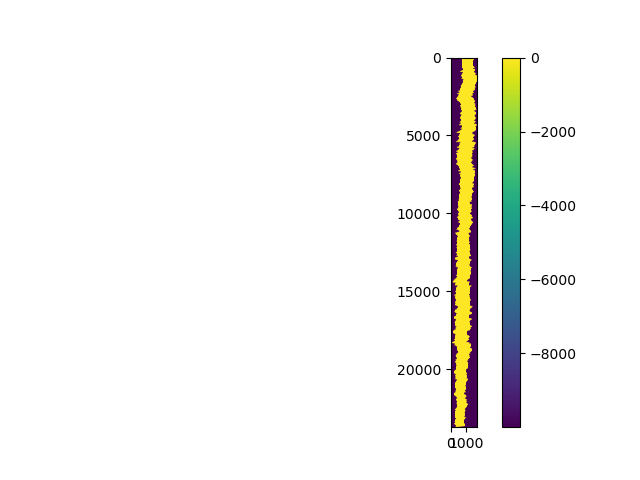

In [3]:
fig = plt.figure()
plt.imshow(obs[...,8])
plt.colorbar()
plt.show()

In [7]:
path_km = obs[:, :, 0]/1000
to_sensor_zenith = obs[:, :, 2]

In [26]:
for i in range(obs.shape[-1]):
    print(i, np.min(obs[...,i]))

0 nan
1 nan
2 nan
3 nan
4 nan
5 nan
6 -9999.0
7 -9999.0
8 -9999.0
9 nan
10 nan


In [2]:
wl = np.loadtxt('wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('wl_nan.txt')

base_dir = '2018/rccs/'

# prepare representative single pxs
fp = '2018/rccs/single_pxs_cal_tarp.pkl'
with open(fp, 'rb') as f:
    single_px = pickle.load(f)

def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))

In [3]:
fids = [x for x in single_px['rdn'].keys() if '20180611' in x] # just cal tarp overflights
fid = fids[0]
fid

'NIS01_20180611_172310'

In [4]:
fp_config = glob(os.path.join(base_dir, f'{fid}_6c', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp_config)

# set up forward model, io, inv according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

INFO:root:Loading config file: 2018/rccs/NIS01_20180611_172310_6c/config/NIS01_20180611_172310_isofit.json
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:/store/carroll/repos/isofit/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/rccs/NIS01_20180611_172310_6c/data/wavelengths.txt
INFO:/store/carroll/repos/isofit/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/repos/isofit/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


In [5]:
target = 'white_tarp'
rdn_ = single_px['rdn'][fid][target]
obs_ = single_px['obs'][fid][target]
loc_ = single_px['loc'][fid][target]
geom = Geometry(obs=obs_, loc=loc_)      

In [7]:
geom.__dict__

{'observer_zenith': 8.603934,
 'observer_azimuth': 195.27509,
 'solar_zenith': 26.503805,
 'solar_azimuth': 122.5682,
 'observer_altitude_km': 2.538022106217908,
 'surface_elevation_km': 1.6125338439941406,
 'earth_sun_distance': None,
 'esd_factor': None,
 'earth_sun_distance_reference': array([[  1.,   1.],
        [  2.,   1.],
        [  3.,   1.],
        [  4.,   1.],
        [  5.,   1.],
        [  6.,   1.],
        [  7.,   1.],
        [  8.,   1.],
        [  9.,   1.],
        [ 10.,   1.],
        [ 11.,   1.],
        [ 12.,   1.],
        [ 13.,   1.],
        [ 14.,   1.],
        [ 15.,   1.],
        [ 16.,   1.],
        [ 17.,   1.],
        [ 18.,   1.],
        [ 19.,   1.],
        [ 20.,   1.],
        [ 21.,   1.],
        [ 22.,   1.],
        [ 23.,   1.],
        [ 24.,   1.],
        [ 25.,   1.],
        [ 26.,   1.],
        [ 27.,   1.],
        [ 28.,   1.],
        [ 29.,   1.],
        [ 30.,   1.],
        [ 31.,   1.],
        [ 32.,   1.],
       

In [12]:
surface_elevation_km = geom.surface_elevation_km
path_length_km = geom.path_length_km
observer_altitude_km = geom.observer_altitude_km


surface_elevation_km, path_length_km, observer_altitude_km

(1.6125338439941406, 0.9360221557617188, 2.538022106217908)

In [11]:
surface_elevation_km + path_length_km

2.5485559997558593

In [14]:
observer_altitude_km_calc = (
    surface_elevation_km + np.cos(np.deg2rad(geom.observer_zenith)) * path_length_km
)
observer_altitude_km_calc

2.538022106217908